# TB-DOTS CAR CDSS: Balanced Hybrid Bi-LSTM Failure-Risk Prediction

This notebook trains and evaluates the temporal Hybrid Bi-LSTM used by the CDSS monthly risk workflow.

The model uses the clinically convenient output convention:

- `1 = Failure` for Died, Lost to Follow-Up, or Not Evaluated
- `0 = Success` for Cured or Treatment Completed
- model logit = `P(Failure)` after sigmoid

Important: `P(Failure)` output does not mean the model should be biased toward Failure. Training and threshold selection are balanced around both outcomes. Failure recall and false-success cases are still reported as safety diagnostics, but the selected model must also preserve Success recall and class-rate calibration.

## 0. Reproducibility and Configuration

Run this notebook from anywhere inside the repository. Paths are resolved by walking up to the repository root.

In [1]:
import json
import math
import os
import random
import sys
import warnings
from dataclasses import asdict, dataclass
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

REPO_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "dataset").exists() and (p / "models").exists()),
    Path.cwd(),
)
DATA_DIR = REPO_ROOT / "dataset" / "temporal"
OUTPUT_DIR = REPO_ROOT / "models" / "Temporal" / "v2" / "output" / "hybrid_lstm_failure_positive"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_ROOT / "models" / "Temporal"))

print(f"Device     : {DEVICE}")
print(f"PyTorch    : {torch.__version__}")
print(f"Repo root  : {REPO_ROOT}")
print(f"Data dir   : {DATA_DIR}")
print(f"Output dir : {OUTPUT_DIR}")

Device     : cpu
PyTorch    : 2.11.0+cpu
Repo root  : C:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS
Data dir   : C:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\dataset\temporal
Output dir : C:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\hybrid_lstm_failure_positive


## 1. Data Loading and Label Convention

The preprocessing helper returns the original temporal arrays and patient-level outcome label where the old convention was `1 = Success`. This notebook immediately converts it to `1 = Failure`.

All scalers are fit on the training split only, then applied to validation/test/full arrays.

In [2]:
import model_utils as mu
import importlib
mu = importlib.reload(mu)  # ensure latest model_utils changes are loaded

csv_path = DATA_DIR / "output" / "cleaned_human_readable.csv"
model_data = mu.prepare_default_model_inputs(
    str(csv_path),
    train_frac=0.70,
    val_frac=0.20,
    test_frac=0.10,
    random_state=SEED,
    drop_feature_cols=mu.get_temporal_v2_drop_feature_cols(),
    imputation_policy="deployment_simple",
)

X_temporal_raw = np.asarray(model_data["X_temporal"], dtype=np.float32)
X_static_raw = np.asarray(model_data["X_static"], dtype=np.float32)
y_success = np.asarray(model_data["y"], dtype=np.int64)
y_failure = (1 - y_success).astype(np.int64)

train_idx = np.asarray(model_data["train_idx"], dtype=np.int64)
val_idx = np.asarray(model_data["val_idx"], dtype=np.int64)
test_idx = np.asarray(model_data["test_idx"], dtype=np.int64)
df = model_data["df"].reset_index(drop=True)

static_feature_names = list(model_data["static_feature_names"])
temporal_feature_names = list(model_data["temporal_feature_names"])
feature_policy_version = model_data.get("feature_policy_version", "custom")
dropped_feature_cols = list(model_data.get("dropped_feature_cols", []))
static_mnar_indicators = list(model_data.get("static_missing_indicator_names", []))
temporal_mnar_indicators = list(model_data.get("temporal_missing_indicator_names", []))

# Scale only continuous features; keep one-hots/missing flags as 0/1.
scaled = mu.scale_full_arrays_selective(
    X_static_raw,
    X_temporal_raw,
    train_idx,
    static_feature_names=static_feature_names,
    temporal_feature_names=temporal_feature_names,
)
X_static = np.asarray(scaled["X_static_scaled"], dtype=np.float32)
X_temporal = np.asarray(scaled["X_temporal_scaled"], dtype=np.float32)

# Persist full-length mean/scale arrays for reproducible deployment.
mu.save_scalers(
    {"mean_": scaled["static_full_mean"], "scale_": scaled["static_full_scale"]},
    {"mean_": scaled["temporal_full_mean"], "scale_": scaled["temporal_full_scale"]},
    str(DATA_DIR),
)

def split_counts(indices):
    y = y_failure[indices]
    return {"success": int((y == 0).sum()), "failure": int((y == 1).sum()), "total": int(len(y))}

print(f"Temporal array : {X_temporal.shape}")
print(f"Static array   : {X_static.shape}")
print(f"Temporal names : {len(temporal_feature_names)}")
print(f"Static names   : {len(static_feature_names)}")
print(f"Feature policy : {feature_policy_version}")
print(f"Dropped cols   : {dropped_feature_cols}")
print(f"Label counts   : Success={int((y_failure == 0).sum())}, Failure={int((y_failure == 1).sum())}")
print(f"Train split    : {split_counts(train_idx)}")
print(f"Val split      : {split_counts(val_idx)}")
print(f"Test split     : {split_counts(test_idx)}")


STAGE 3: Data Cleaning & Type Coercion
  Parsed 'date_of_birth': 437/437 valid dates


  Parsed 'date_of_diagnosis': 437/437 valid dates
  Parsed 'date_of_notification': 437/437 valid dates
  Parsed 'treatment_start_date': 437/437 valid dates
  Parsed 'date_of_outcome': 437/437 valid dates
  Parsed 'intensive_phase_start_date': 437/437 valid dates


  Parsed 'intensive_phase_end_date': 437/437 valid dates
  Parsed 'continuation_phase_start_date': 437/437 valid dates
  Parsed 'continuation_phase_end_date': 437/437 valid dates
  Fixed 1 rows where treatment_start_date < date_of_diagnosis (set to date_of_diagnosis)
  Parsed 'weight' -> 'weight_kg': 437 valid (raw 'weight' standardized to 'XX.X kg')
  Parsed 'height' -> 'height_cm': 437 valid (raw 'height' standardized to 'XXX.X cm')
  Parsed 'o2_sat': 437 valid
  Parsed 'xpert_mtb_rif' -> binary: 437 valid
  Parsed 'smear_microscopy' -> binary: 437 valid
  Cleaned monthly columns M0-M12 (weight, height, adherence, smear, xpert, doses)

  --- Clinical Sanity Checks ---
    age: all values in range [0-110 years]
    weight_kg: clipped 1 below 10 and 0 above 180 kg
    height_cm: all values in range [80-220 cm]
    bp_systolic: all values in range [60-220 mmHg]
    bp_diastolic: all values in range [30-140 mmHg]
    heart_rate: all values in range [20-250 bpm]
    o2_sat: all values in 

    Monthly weight/height/adherence/doses/tests: clipped to plausible ranges

STAGE 4: Categorical Harmonization
  Harmonized 'sex': {'Male': 299, 'Female': 138}
  Harmonized 'civil_status': {'Single': 273, 'Married': 132, 'Widowed': 32}
  Harmonized 'nationality': {'Filipino': 437}
  Harmonized 'diagnosis': {'TB Disease': 424, 'TB Infection': 13}
  Harmonized 'bacteriologic_status': {'Clinically Diagnosed': 289, 'Bacteriologically Confirmed': 148}
  Harmonized 'treatment_regimen': {'Regimen 1': 430, 'Regimen 2': 7}
  Harmonized 'outcome': {'Treatment Completed': 321, 'Lost to Follow-Up': 58, 'Cured': 47, 'Died': 9, 'Not Evaluated': 2}
  Harmonized 'case_registration_group': {'New': 415, 'Relapse': 19}
  Harmonized 'drug_resistance_bacteriological_status': {'Drug Susceptible': 437}
  Harmonized 'co_morbidities' (multi-answer preserved):
    {'No Known Comorbidity': 327, 'Hypertension': 27, 'Diabetes Mellitus': 24, 'Diabetes Mellitus, Hypertension': 5, 'Nk': 5, 'Cancer': 4, 'Hpn': 4, 'A

  Temporal DataFrame shape: (5681, 18) (437 patients x 13 months)
  Static DataFrame shape: (437, 58)

Temporal array : (437, 13, 16)
Static array   : (437, 22)
Temporal names : 16
Static names   : 22
Feature policy : temporal_v2_cleaned_output_facility_v1
Dropped cols   : ['bacteriologic_status', 'case_registration_group', 'chest_x_ray_at_case_notification', 'civil_status', 'co_morbidities', 'continuation_phase_end_date', 'continuation_phase_start_date', 'data_year', 'date_of_birth', 'date_of_outcome', 'diagnosis', 'drug_resistance_bacteriological_status', 'facility', 'height', 'intensive_phase_end_date', 'is_missing_bacteriologic_status', 'is_missing_case_registration_group', 'is_missing_chest_x_ray_at_case_notification', 'is_missing_civil_status', 'is_missing_co_morbidities', 'is_missing_diagnosis', 'is_missing_drug_resistance_bacteriological_status', 'is_missing_nationality', 'is_missing_outcome', 'is_missing_sex', 'is_missing_treatment_regimen', 'name_of_diagnosing_facility', 'nam

## 2. Dataset Balance

The dataset is small and imbalanced, so raw accuracy is not sufficient. The main safety target is high Failure recall and low false-success count.

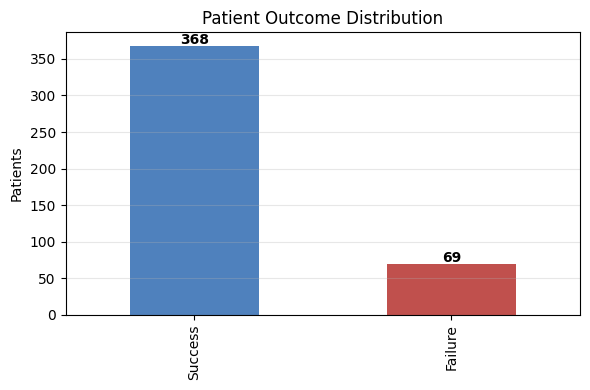

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = pd.Series({"Success": int((y_failure == 0).sum()), "Failure": int((y_failure == 1).sum())})
counts.plot(kind="bar", ax=ax, color=["#4f81bd", "#c0504d"])
ax.set_title("Patient Outcome Distribution")
ax.set_ylabel("Patients")
ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Progressive Temporal Dataset

Training still uses progressive patient-month samples so the model learns M0-M12 inference behavior. To reduce overfitting, the training loader now uses normal shuffling instead of a `WeightedRandomSampler`.

Why: the dataset has only a small number of Failure patients. Weighted sampling repeatedly shows those same patients to the network and can make the model memorize minority cases. Class balance is handled only through the candidate loss function, not through both sampler and loss weighting.

Validation and test include full-sequence patient-level loaders so model selection is not driven only by inflated progressive-row metrics.

In [4]:
class ProgressiveTBDataset(Dataset):
    def __init__(self, X_temporal, X_static, y_failure, patient_idx, max_month=12):
        temporal_rows = []
        static_rows = []
        seq_lens = []
        labels = []
        patient_ids = []
        months = []

        for pid in patient_idx.tolist():
            for month in range(max_month + 1):
                xt = np.zeros_like(X_temporal[pid], dtype=np.float32)
                xt[: month + 1] = X_temporal[pid, : month + 1]
                temporal_rows.append(xt)
                static_rows.append(X_static[pid])
                seq_lens.append(month + 1)
                labels.append(y_failure[pid])
                patient_ids.append(pid)
                months.append(month)

        self.x_temporal = torch.tensor(np.asarray(temporal_rows), dtype=torch.float32)
        self.x_static = torch.tensor(np.asarray(static_rows), dtype=torch.float32)
        self.seq_lens = torch.tensor(np.asarray(seq_lens), dtype=torch.long)
        self.labels = torch.tensor(np.asarray(labels), dtype=torch.float32)
        self.patient_ids = np.asarray(patient_ids, dtype=np.int64)
        self.months = np.asarray(months, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.x_temporal[idx], self.x_static[idx], self.seq_lens[idx], self.labels[idx]


class FullSequenceTBDataset(Dataset):
    def __init__(self, X_temporal, X_static, y_failure, patient_idx):
        self.x_temporal = torch.tensor(X_temporal[patient_idx], dtype=torch.float32)
        self.x_static = torch.tensor(X_static[patient_idx], dtype=torch.float32)
        self.seq_lens = torch.full((len(patient_idx),), X_temporal.shape[1], dtype=torch.long)
        self.labels = torch.tensor(y_failure[patient_idx], dtype=torch.float32)
        self.patient_ids = np.asarray(patient_idx, dtype=np.int64)
        self.months = np.full(len(patient_idx), X_temporal.shape[1] - 1, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.x_temporal[idx], self.x_static[idx], self.seq_lens[idx], self.labels[idx]


def append_synthetic_counterfactuals(train_ds, n_each=128):
    # Balanced synthetic counterfactuals to teach early-month sensitivity.
    # Only low-risk (success) and high-risk (failure) -- 128:128 balanced.
    feat_to_i = {n: i for i, n in enumerate(temporal_feature_names)}
    mean_t = np.asarray(scaled["temporal_full_mean"], dtype=np.float32)
    scale_t = np.asarray(scaled["temporal_full_scale"], dtype=np.float32)

    def make_raw_template(n_samples):
        raw = np.full((n_samples, 13, len(temporal_feature_names)), np.nan, dtype=np.float32)
        for n in temporal_feature_names:
            if n.startswith("is_missing_"):
                raw[:, :, feat_to_i[n]] = 1.0
        return raw

    def scale_raw(raw):
        xt = (raw - mean_t) / scale_t
        return np.nan_to_num(xt, nan=0.0).astype(np.float32)

    xs = torch.zeros((n_each, train_ds.x_static.shape[1]), dtype=torch.float32)

    # 1) Low-risk M1 labeled SUCCESS.
    raw_low = make_raw_template(n_each)
    if "smear_tb_lamp" in feat_to_i:
        raw_low[:, 0, feat_to_i["smear_tb_lamp"]] = 1.0
    if "is_missing_smear_tb_lamp" in feat_to_i:
        raw_low[:, 0, feat_to_i["is_missing_smear_tb_lamp"]] = 0.0

    for k, v in [
        ("weight", 55.0),
        ("height", 155.0),
        ("monthly_doses_taken", 19.0),
        ("monthly_missed_doses", 0.0),
        ("cumulative_doses_taken", 19.0),
        ("pct_adherence", 1.0),
        ("smear_tb_lamp", 0.0),
        ("xpert_mtb_rif", 0.0),
    ]:
        if k in feat_to_i:
            raw_low[:, 1, feat_to_i[k]] = float(v)

    for k in [
        "is_missing_weight",
        "is_missing_height",
        "is_missing_monthly_doses_taken",
        "is_missing_monthly_missed_doses",
        "is_missing_cumulative_doses_taken",
        "is_missing_pct_adherence",
        "is_missing_smear_tb_lamp",
        "is_missing_xpert_mtb_rif",
    ]:
        if k in feat_to_i:
            raw_low[:, 1, feat_to_i[k]] = 0.0

    xt_low = torch.tensor(scale_raw(raw_low), dtype=torch.float32)
    seq_low = torch.full((n_each,), 2, dtype=torch.long)
    y_low = torch.zeros((n_each,), dtype=torch.float32)

    # 2) High-risk M1 labeled FAILURE.
    raw_high = make_raw_template(n_each)
    if "smear_tb_lamp" in feat_to_i:
        raw_high[:, 0, feat_to_i["smear_tb_lamp"]] = 1.0
    if "is_missing_smear_tb_lamp" in feat_to_i:
        raw_high[:, 0, feat_to_i["is_missing_smear_tb_lamp"]] = 0.0

    for k, v in [
        ("weight", 55.0),
        ("height", 155.0),
        ("monthly_doses_taken", 2.0),
        ("monthly_missed_doses", 17.0),
        ("cumulative_doses_taken", 2.0),
        ("pct_adherence", 2.0 / 19.0),
        ("smear_tb_lamp", 1.0),
        ("xpert_mtb_rif", 1.0),
    ]:
        if k in feat_to_i:
            raw_high[:, 1, feat_to_i[k]] = float(v)

    for k in [
        "is_missing_weight",
        "is_missing_height",
        "is_missing_monthly_doses_taken",
        "is_missing_monthly_missed_doses",
        "is_missing_cumulative_doses_taken",
        "is_missing_pct_adherence",
        "is_missing_smear_tb_lamp",
        "is_missing_xpert_mtb_rif",
    ]:
        if k in feat_to_i:
            raw_high[:, 1, feat_to_i[k]] = 0.0

    xt_high = torch.tensor(scale_raw(raw_high), dtype=torch.float32)
    seq_high = torch.full((n_each,), 2, dtype=torch.long)
    y_high = torch.ones((n_each,), dtype=torch.float32)

    train_ds.x_temporal = torch.cat([train_ds.x_temporal, xt_low, xt_high], dim=0)
    train_ds.x_static = torch.cat([train_ds.x_static, xs, xs.clone()], dim=0)
    train_ds.seq_lens = torch.cat([train_ds.seq_lens, seq_low, seq_high], dim=0)
    train_ds.labels = torch.cat([train_ds.labels, y_low, y_high], dim=0)

    train_ds.patient_ids = np.concatenate([
        train_ds.patient_ids,
        -np.ones((n_each,), dtype=np.int64),
        -np.ones((n_each,), dtype=np.int64),
    ])
    train_ds.months = np.concatenate([
        train_ds.months,
        np.full((n_each,), 1, dtype=np.int64),
        np.full((n_each,), 1, dtype=np.int64),
    ])



BATCH_SIZE = 64
train_ds = ProgressiveTBDataset(X_temporal, X_static, y_failure, train_idx)
val_ds = ProgressiveTBDataset(X_temporal, X_static, y_failure, val_idx)
val_full_ds = FullSequenceTBDataset(X_temporal, X_static, y_failure, val_idx)
test_full_ds = FullSequenceTBDataset(X_temporal, X_static, y_failure, test_idx)

append_synthetic_counterfactuals(train_ds, n_each=128)

# Oversample early-month failure prefixes.
months = train_ds.months.astype(np.int64)
labels = train_ds.labels.detach().cpu().numpy().astype(np.float32)
month_weight = np.where(months <= 2, 3.0, np.where(months <= 5, 2.0, 1.0)).astype(np.float32)
label_weight = np.where(labels >= 0.5, 2.0, 1.0).astype(np.float32)
sample_weights = (month_weight * label_weight).astype(np.float64)

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, drop_last=False)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
val_full_loader = DataLoader(val_full_ds, batch_size=256, shuffle=False)
test_full_loader = DataLoader(test_full_ds, batch_size=256, shuffle=False)

print(f"Train samples       : {len(train_ds)} progressive rows from {len(train_idx)} patients (+ synthetic)")
print(f"Val progressive rows: {len(val_ds)} progressive rows from {len(val_idx)} patients")
print(f"Val full sequences  : {len(val_full_ds)} patients")
print(f"Test full sequences : {len(test_full_ds)} patients")
print("Sampler             : WeightedRandomSampler (oversample early failure prefixes)")


Train samples       : 4221 progressive rows from 305 patients (+ synthetic)
Val progressive rows: 1131 progressive rows from 87 patients
Val full sequences  : 87 patients
Test full sequences : 45 patients
Sampler             : WeightedRandomSampler (oversample early failure prefixes)


## 4. Reduced-Capacity Hybrid Bi-LSTM Architecture

In [5]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_size, max(hidden_size // 2, 8)),
            nn.Tanh(),
            nn.Linear(max(hidden_size // 2, 8), 1, bias=False),
        )

    def forward(self, lstm_out, seq_lens=None):
        scores = self.attn(lstm_out).squeeze(-1)
        if seq_lens is not None:
            max_len = lstm_out.size(1)
            time_idx = torch.arange(max_len, device=lstm_out.device).unsqueeze(0)
            mask = time_idx >= seq_lens.unsqueeze(1)
            scores = scores.masked_fill(mask, float("-inf"))
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), lstm_out).squeeze(1)
        return context, weights


class TB_LSTM_CDSS(nn.Module):
    def __init__(
        self,
        temporal_features,
        static_features,
        lstm_hidden=32,
        lstm_layers=1,
        dropout=0.4,
        static_hidden=32,
        static_out=16,
        classifier_hidden=32,
    ):
        super().__init__()
        self.lstm_hidden = lstm_hidden
        self.lstm_layers = lstm_layers
        self.dropout = dropout
        self.static_hidden = static_hidden
        self.static_out = static_out
        self.classifier_hidden = classifier_hidden

        self.lstm = nn.LSTM(
            input_size=temporal_features,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        temporal_out = lstm_hidden * 2
        self.temporal_attention = TemporalAttention(temporal_out)
        self.temporal_norm = nn.LayerNorm(temporal_out)
        self.static_net = nn.Sequential(
            nn.Linear(static_features, static_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(static_hidden, static_out),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Sequential(
            nn.Linear(temporal_out + static_out, classifier_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_hidden, 1),
        )

    def forward(self, x_temporal, x_static, seq_lens=None):
        if seq_lens is not None:
            packed = nn.utils.rnn.pack_padded_sequence(
                x_temporal,
                seq_lens.cpu().clamp(min=1),
                batch_first=True,
                enforce_sorted=False,
            )
            packed_out, _ = self.lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
                packed_out,
                batch_first=True,
                total_length=x_temporal.size(1),
            )
        else:
            lstm_out, _ = self.lstm(x_temporal)

        context, attn_weights = self.temporal_attention(lstm_out, seq_lens)
        context = self.temporal_norm(context)
        static_repr = self.static_net(x_static)
        fused = torch.cat([context, static_repr], dim=1)
        logit = self.classifier(fused).squeeze(-1)
        return logit, attn_weights


preview_model = TB_LSTM_CDSS(
    temporal_features=X_temporal.shape[2],
    static_features=X_static.shape[1],
    lstm_hidden=32,
    lstm_layers=1,
    dropout=0.4,
    static_hidden=32,
    static_out=16,
    classifier_hidden=32,
).to(DEVICE)

total_params = sum(p.numel() for p in preview_model.parameters())
trainable_params = sum(p.numel() for p in preview_model.parameters() if p.requires_grad)
print(f"Reduced-capacity preview: {total_params:,} total parameters, {trainable_params:,} trainable")
print(preview_model)
del preview_model

Reduced-capacity preview: 18,929 total parameters, 18,929 trainable
TB_LSTM_CDSS(
  (lstm): LSTM(16, 32, batch_first=True, bidirectional=True)
  (temporal_attention): TemporalAttention(
    (attn): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): Tanh()
      (2): Linear(in_features=32, out_features=1, bias=False)
    )
  )
  (temporal_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (static_net): Sequential(
    (0): Linear(in_features=22, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=80, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 5. Overfit-Reduction Training Strategy

The notebook now favors a less overfitted model, even if headline accuracy is lower.

Changes from the previous version:

- smaller candidate models: `hidden=32` or `48`, one LSTM layer
- no weighted sampler
- stricter early stopping: `epochs=60`, `patience=8`
- model selection penalizes train-validation gap and class-rate drift
- final deployment status can be `ACCEPTABLE`, `REVIEW`, or `REJECT_STRONG_OVERFIT`

The selected model must balance both classes. It should not simply predict Failure to avoid false-success cases.

In [6]:
@dataclass
class EvalResult:
    split: str
    threshold: float
    accuracy: float
    balanced_accuracy: float
    macro_f1: float
    failure_precision: float
    failure_recall: float
    failure_f1: float
    success_precision: float
    success_recall: float
    success_f1: float
    min_class_recall: float
    roc_auc_failure: float | None
    pr_auc_failure: float | None
    false_success_count: int
    false_failure_count: int
    actual_failure_rate: float
    predicted_failure_rate: float
    class_rate_gap: float
    mean_p_failure_true_failure: float
    mean_p_failure_true_success: float
    confusion_labels_failure_success: list


def predict_loader(model, loader):
    model.eval()
    probs, labels, patient_ids, months, attentions = [], [], [], [], []
    start = 0
    with torch.no_grad():
        for x_t, x_s, seq_lens, y in loader:
            x_t = x_t.to(DEVICE)
            x_s = x_s.to(DEVICE)
            seq_lens = seq_lens.to(DEVICE)
            logits, attn = model(x_t, x_s, seq_lens=seq_lens)
            batch_probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
            probs.append(batch_probs)
            labels.append(y.numpy().astype(np.int64).reshape(-1))
            attentions.append(attn.cpu().numpy())
            batch_len = len(y)
            if hasattr(loader.dataset, "patient_ids"):
                patient_ids.append(loader.dataset.patient_ids[start : start + batch_len])
                months.append(loader.dataset.months[start : start + batch_len])
            start += batch_len
    result = {
        "probs": np.concatenate(probs),
        "labels": np.concatenate(labels),
        "attentions": np.concatenate(attentions),
    }
    if patient_ids:
        result["patient_ids"] = np.concatenate(patient_ids)
        result["months"] = np.concatenate(months)
    return result


def evaluate_probs(split, probs, labels, threshold):
    preds = (probs >= threshold).astype(np.int64)
    failure_mask = labels == 1
    success_mask = labels == 0
    cm = confusion_matrix(labels, preds, labels=[1, 0])
    false_success = int(((labels == 1) & (preds == 0)).sum())
    false_failure = int(((labels == 0) & (preds == 1)).sum())
    actual_failure_rate = float(labels.mean())
    predicted_failure_rate = float(preds.mean())
    failure_recall = float(recall_score(labels, preds, pos_label=1, zero_division=0))
    success_recall = float(recall_score(labels, preds, pos_label=0, zero_division=0))
    try:
        roc_auc = float(roc_auc_score(labels, probs))
    except ValueError:
        roc_auc = None
    try:
        pr_auc = float(average_precision_score(labels, probs))
    except ValueError:
        pr_auc = None
    return EvalResult(
        split=split,
        threshold=float(threshold),
        accuracy=float(accuracy_score(labels, preds)),
        balanced_accuracy=float(balanced_accuracy_score(labels, preds)),
        macro_f1=float(f1_score(labels, preds, average="macro", zero_division=0)),
        failure_precision=float(precision_score(labels, preds, pos_label=1, zero_division=0)),
        failure_recall=failure_recall,
        failure_f1=float(f1_score(labels, preds, pos_label=1, zero_division=0)),
        success_precision=float(precision_score(labels, preds, pos_label=0, zero_division=0)),
        success_recall=success_recall,
        success_f1=float(f1_score(labels, preds, pos_label=0, zero_division=0)),
        min_class_recall=float(min(failure_recall, success_recall)),
        roc_auc_failure=roc_auc,
        pr_auc_failure=pr_auc,
        false_success_count=false_success,
        false_failure_count=false_failure,
        actual_failure_rate=actual_failure_rate,
        predicted_failure_rate=predicted_failure_rate,
        class_rate_gap=float(abs(predicted_failure_rate - actual_failure_rate)),
        mean_p_failure_true_failure=float(probs[failure_mask].mean()) if failure_mask.any() else float("nan"),
        mean_p_failure_true_success=float(probs[success_mask].mean()) if success_mask.any() else float("nan"),
        confusion_labels_failure_success=cm.astype(int).tolist(),
    )


def balanced_selection_score(result):
    # Composite score: 0.6 * AUC + 0.4 * Recall(Failure).
    # AUC measures discrimination (threshold-independent); Recall(F) prioritizes catching the minority class.
    auc = result.roc_auc_failure if result.roc_auc_failure is not None else 0.0
    return 0.6 * auc + 0.4 * result.failure_recall


def print_eval(result):
    print(f"\n{result.split} @ threshold={result.threshold:.2f}")
    print(f"accuracy             : {result.accuracy:.4f}")
    print(f"balanced_accuracy    : {result.balanced_accuracy:.4f}")
    print(f"macro_f1             : {result.macro_f1:.4f}")
    print(f"failure_precision    : {result.failure_precision:.4f}")
    print(f"failure_recall       : {result.failure_recall:.4f}")
    print(f"success_precision    : {result.success_precision:.4f}")
    print(f"success_recall       : {result.success_recall:.4f}")
    print(f"min_class_recall     : {result.min_class_recall:.4f}")
    print(f"roc_auc_failure      : {result.roc_auc_failure}")
    print(f"pr_auc_failure       : {result.pr_auc_failure}")
    print(f"false_success_count  : {result.false_success_count}")
    print(f"false_failure_count  : {result.false_failure_count}")
    print(f"actual_failure_rate  : {result.actual_failure_rate:.4f}")
    print(f"pred_failure_rate    : {result.predicted_failure_rate:.4f}")
    print(f"class_rate_gap       : {result.class_rate_gap:.4f}")
    print(f"mean P(Failure)|Failure: {result.mean_p_failure_true_failure:.4f}")
    print(f"mean P(Failure)|Success: {result.mean_p_failure_true_success:.4f}")
    print(f"confusion labels [Failure, Success]: {result.confusion_labels_failure_success}")


def find_balanced_threshold(model, val_loader):
    pred = predict_loader(model, val_loader)
    probs = pred["probs"]
    labels = pred["labels"]
    rows = []
    best_threshold = 0.5
    best_score = -float("inf")

    for threshold in np.linspace(0.05, 0.95, 91):
        result = evaluate_probs("val_threshold_search", probs, labels, threshold)
        score = balanced_selection_score(result)
        rows.append({
            "threshold": float(threshold),
            "score": float(score),
            "balanced_accuracy": result.balanced_accuracy,
            "macro_f1": result.macro_f1,
            "failure_recall": result.failure_recall,
            "success_recall": result.success_recall,
            "min_class_recall": result.min_class_recall,
            "actual_failure_rate": result.actual_failure_rate,
            "predicted_failure_rate": result.predicted_failure_rate,
            "class_rate_gap": result.class_rate_gap,
            "false_success": result.false_success_count,
            "false_failure": result.false_failure_count,
        })
        if score > best_score:
            best_score = score
            best_threshold = float(threshold)

    return best_threshold, pd.DataFrame(rows), pred


In [7]:
def build_model(spec):
    return TB_LSTM_CDSS(
        temporal_features=X_temporal.shape[2],
        static_features=X_static.shape[1],
        lstm_hidden=spec["lstm_hidden"],
        lstm_layers=spec["lstm_layers"],
        dropout=spec["dropout"],
        static_hidden=spec["static_hidden"],
        static_out=spec["static_out"],
        classifier_hidden=spec["classifier_hidden"],
    ).to(DEVICE)


def make_criterion(pos_weight_value):
    if pos_weight_value is None:
        return nn.BCEWithLogitsLoss(), "unweighted BCEWithLogitsLoss"
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight), f"BCEWithLogitsLoss(pos_weight={pos_weight.item():.4f})"


def train_model(model, train_loader, val_full_loader, candidate_name, pos_weight_value=None, epochs=60, lr=8e-4, patience=8, weight_decay=5e-4):
    criterion, criterion_name = make_criterion(pos_weight_value)
    print(f"Training objective [{candidate_name}]: {criterion_name}")
    print("Early stopping target: validation full-sequence composite score (0.6*AUC + 0.4*Recall(Failure))")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6)

    history = {"train_loss": [], "val_full_score": [], "val_full_balanced_accuracy": [], "val_full_macro_f1": []}
    best_score = -float("inf")
    best_state = None
    best_threshold = 0.5
    best_epoch = 0
    stale_epochs = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for x_t, x_s, seq_lens, labels in train_loader:
            x_t = x_t.to(DEVICE)
            x_s = x_s.to(DEVICE)
            seq_lens = seq_lens.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits, _ = model(x_t, x_s, seq_lens=seq_lens)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            train_losses.append(float(loss.detach().cpu()))

        threshold, _, val_pred = find_balanced_threshold(model, val_full_loader)
        val_result = evaluate_probs(f"val_full_{candidate_name}", val_pred["probs"], val_pred["labels"], threshold)
        val_score = balanced_selection_score(val_result)

        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_full_score"].append(val_score)
        history["val_full_balanced_accuracy"].append(val_result.balanced_accuracy)
        history["val_full_macro_f1"].append(val_result.macro_f1)
        scheduler.step(val_score)

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"[{candidate_name}] Epoch {epoch:03d}/{epochs}: "
                f"train_loss={history['train_loss'][-1]:.4f} "
                f"val_score={val_score:.4f} "
                f"val_bal_acc={val_result.balanced_accuracy:.4f} "
                f"val_macro_f1={val_result.macro_f1:.4f} "
                f"threshold={threshold:.2f}"
            )

        if val_score > best_score:
            best_score = val_score
            best_threshold = threshold
            best_epoch = epoch
            stale_epochs = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                print(f"[{candidate_name}] Early stopping at epoch {epoch}; best epoch={best_epoch}, best val_score={best_score:.4f}")
                break

    if best_state is None:
        raise RuntimeError("No best model state was captured.")
    model.load_state_dict(best_state)
    return model, history, best_state, best_threshold, best_score


def clinical_counterfactual_metrics(model):
    # Return (p_base_M0, p_lowrisk_M1, p_highrisk_M1).
    feat_to_i = {n: i for i, n in enumerate(temporal_feature_names)}
    mean_t = np.asarray(scaled["temporal_full_mean"], dtype=np.float32)
    scale_t = np.asarray(scaled["temporal_full_scale"], dtype=np.float32)

    static_scaled = np.zeros((len(static_feature_names),), dtype=np.float32)

    def make_raw_template():
        raw = np.full((13, len(temporal_feature_names)), np.nan, dtype=np.float32)
        for n in temporal_feature_names:
            if n.startswith('is_missing_'):
                raw[:, feat_to_i[n]] = 1.0
        return raw

    def scale_raw(raw):
        return np.nan_to_num((raw - mean_t) / scale_t, nan=0.0).astype(np.float32)

    # Base M0 smear+
    raw_base = make_raw_template()
    if 'smear_tb_lamp' in feat_to_i:
        raw_base[0, feat_to_i['smear_tb_lamp']] = 1.0
    if 'is_missing_smear_tb_lamp' in feat_to_i:
        raw_base[0, feat_to_i['is_missing_smear_tb_lamp']] = 0.0

    # Low-risk M1
    raw_low = raw_base.copy()
    for k, v in [
        ('weight', 55.0),
        ('height', 155.0),
        ('monthly_doses_taken', 19.0),
        ('monthly_missed_doses', 0.0),
        ('cumulative_doses_taken', 19.0),
        ('pct_adherence', 1.0),
        ('smear_tb_lamp', 0.0),
        ('xpert_mtb_rif', 0.0),
    ]:
        if k in feat_to_i:
            raw_low[1, feat_to_i[k]] = float(v)
    for k in [
        'is_missing_weight',
        'is_missing_height',
        'is_missing_monthly_doses_taken',
        'is_missing_monthly_missed_doses',
        'is_missing_cumulative_doses_taken',
        'is_missing_pct_adherence',
        'is_missing_smear_tb_lamp',
        'is_missing_xpert_mtb_rif',
    ]:
        if k in feat_to_i:
            raw_low[1, feat_to_i[k]] = 0.0

    # High-risk M1
    raw_high = raw_base.copy()
    for k, v in [
        ('weight', 55.0),
        ('height', 155.0),
        ('monthly_doses_taken', 2.0),
        ('monthly_missed_doses', 17.0),
        ('cumulative_doses_taken', 2.0),
        ('pct_adherence', 2.0 / 19.0),
        ('smear_tb_lamp', 1.0),
        ('xpert_mtb_rif', 1.0),
    ]:
        if k in feat_to_i:
            raw_high[1, feat_to_i[k]] = float(v)
    for k in [
        'is_missing_weight',
        'is_missing_height',
        'is_missing_monthly_doses_taken',
        'is_missing_monthly_missed_doses',
        'is_missing_cumulative_doses_taken',
        'is_missing_pct_adherence',
        'is_missing_smear_tb_lamp',
        'is_missing_xpert_mtb_rif',
    ]:
        if k in feat_to_i:
            raw_high[1, feat_to_i[k]] = 0.0

    X_base = scale_raw(raw_base)
    X_low = scale_raw(raw_low)
    X_high = scale_raw(raw_high)

    with torch.no_grad():
        model.eval()
        xs = torch.tensor(static_scaled.reshape(1, -1), dtype=torch.float32, device=DEVICE)

        xtB = torch.tensor(X_base.reshape(1, 13, -1), dtype=torch.float32, device=DEVICE)
        logit_B, _ = model(xtB, xs, seq_lens=torch.tensor([1], dtype=torch.long, device=DEVICE))
        pBase = float(torch.sigmoid(logit_B).detach().cpu().numpy().reshape(-1)[0])

        xtL = torch.tensor(X_low.reshape(1, 13, -1), dtype=torch.float32, device=DEVICE)
        logit_L, _ = model(xtL, xs, seq_lens=torch.tensor([2], dtype=torch.long, device=DEVICE))
        pLow = float(torch.sigmoid(logit_L).detach().cpu().numpy().reshape(-1)[0])

        xtH = torch.tensor(X_high.reshape(1, 13, -1), dtype=torch.float32, device=DEVICE)
        logit_H, _ = model(xtH, xs, seq_lens=torch.tensor([2], dtype=torch.long, device=DEVICE))
        pHigh = float(torch.sigmoid(logit_H).detach().cpu().numpy().reshape(-1)[0])

    return pBase, pLow, pHigh


def candidate_selection_score(train_result, val_full_result, clinical_delta, clinical_highrisk_p):
    gap = max(0.0, train_result.balanced_accuracy - val_full_result.balanced_accuracy)
    overfit_penalty = gap * 0.75

    # Normalize clinical contribution: reward increasing risk and a non-trivial high-risk probability.
    clinical_bonus = 0.0
    if clinical_delta > 0:
        clinical_bonus += min(0.20, clinical_delta) * 2.0
    clinical_bonus += min(0.30, clinical_highrisk_p) * 0.5

    return balanced_selection_score(val_full_result) - overfit_penalty + clinical_bonus


def deployment_status(train_result, val_result, test_result):
    train_val_gap = train_result.balanced_accuracy - val_result.balanced_accuracy
    train_test_gap = train_result.balanced_accuracy - test_result.balanced_accuracy
    if train_val_gap <= 0.10 and train_test_gap <= 0.12:
        return "ACCEPTABLE"
    if train_val_gap <= 0.15 and train_test_gap <= 0.15:
        return "REVIEW"
    return "REJECT_STRONG_OVERFIT"


EPOCHS = 60
PATIENCE = 8
LEARNING_RATE = 8e-4
WEIGHT_DECAY = 5e-4

train_patient_labels = y_failure[train_idx]
n_failure = int((train_patient_labels == 1).sum())
n_success = int((train_patient_labels == 0).sum())
imbalance_ratio = n_success / max(n_failure, 1)

base_specs = [
    {"capacity": "h32_l1_d03", "lstm_hidden": 32, "lstm_layers": 1, "dropout": 0.3, "static_hidden": 32, "static_out": 16, "classifier_hidden": 32},
    {"capacity": "h32_l1_d04", "lstm_hidden": 32, "lstm_layers": 1, "dropout": 0.4, "static_hidden": 32, "static_out": 16, "classifier_hidden": 32},
    {"capacity": "h48_l1_d04", "lstm_hidden": 48, "lstm_layers": 1, "dropout": 0.4, "static_hidden": 32, "static_out": 16, "classifier_hidden": 32},
]
loss_specs = [
    {"loss": "balanced_bce", "pos_weight": None},
    {"loss": "mild_weighted_bce", "pos_weight": float(np.sqrt(imbalance_ratio))},
]
candidate_specs = []
for base in base_specs:
    for loss in loss_specs:
        spec = {**base, **loss}
        spec["name"] = f"{base['capacity']}_{loss['loss']}"
        candidate_specs.append(spec)

candidate_results = []
for spec in candidate_specs:
    print("\n" + "=" * 88)
    print(f"Candidate: {spec['name']}")
    candidate_model = build_model(spec)
    candidate_model, candidate_history, candidate_state, candidate_threshold, candidate_val_score = train_model(
        candidate_model,
        train_loader,
        val_full_loader,
        candidate_name=spec["name"],
        pos_weight_value=spec["pos_weight"],
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        patience=PATIENCE,
        weight_decay=WEIGHT_DECAY,
    )

    candidate_threshold, candidate_threshold_table, candidate_val_pred = find_balanced_threshold(candidate_model, val_full_loader)
    candidate_val_result = evaluate_probs(
        f"val_full_{spec['name']}",
        candidate_val_pred["probs"],
        candidate_val_pred["labels"],
        candidate_threshold,
    )
    candidate_train_pred = predict_loader(candidate_model, train_loader)
    candidate_train_result = evaluate_probs(
        f"train_progressive_{spec['name']}",
        candidate_train_pred["probs"],
        candidate_train_pred["labels"],
        candidate_threshold,
    )
    pBase, pLow, pHigh = clinical_counterfactual_metrics(candidate_model)
    cdelta = (pHigh - pBase)
    sep = (pHigh - pLow)
    print(f"clinical counterfactual: base={pBase:.4f} low={pLow:.4f} high={pHigh:.4f} delta={cdelta:.4f} sep={sep:.4f}")
    candidate_score = candidate_selection_score(candidate_train_result, candidate_val_result, cdelta, pHigh)
    print_eval(candidate_val_result)
    print(f"overfit-aware selection score: {candidate_score:.4f}")
    print(f"train-val balanced accuracy gap: {candidate_train_result.balanced_accuracy - candidate_val_result.balanced_accuracy:.4f}")
    candidate_results.append({
        "name": spec["name"],
        "spec": spec,
        "pos_weight": spec["pos_weight"],
        "model": candidate_model,
        "history": candidate_history,
        "state": candidate_state,
        "threshold": candidate_threshold,
        "threshold_table": candidate_threshold_table,
        "train_result": candidate_train_result,
        "val_result": candidate_val_result,
        "selection_score": candidate_score,
        "clinical_baseline_p": pBase,
        "clinical_highrisk_p": pHigh,
        "clinical_lowrisk_p": pLow,
        "clinical_delta": cdelta,
    })

eligible_candidates = [
    row for row in candidate_results
    if (row["train_result"].balanced_accuracy - row["val_result"].balanced_accuracy) <= 0.10
    and row["val_result"].class_rate_gap <= 0.25
    and row["val_result"].failure_recall >= 0.50
    and row["val_result"].success_recall >= 0.70
    and row.get("clinical_delta", 0.0) >= 0.10
    and row.get("clinical_highrisk_p", 0.0) >= 0.20
    and row.get("clinical_baseline_p", 1.0) <= 0.20
    and (row.get("clinical_highrisk_p", 0.0) - row.get("clinical_lowrisk_p", 0.0)) >= 0.15
]

if eligible_candidates:
    selected_candidate = max(eligible_candidates, key=lambda row: row["selection_score"])
    selection_reason = "Selected from candidates satisfying overfit and class-balance constraints."
else:
    selected_candidate = max(candidate_results, key=lambda row: row["selection_score"])
    selection_reason = "No candidate satisfied all constraints; selected best overfit-penalized score."

model = selected_candidate["model"]
history = selected_candidate["history"]
best_state = selected_candidate["state"]
failure_threshold = selected_candidate["threshold"]
threshold_table = selected_candidate["threshold_table"]
selected_training_objective = selected_candidate["spec"]["loss"]
selected_selection_objective = "0.6_auc_0.4_failure_recall"
selected_model_spec = selected_candidate["spec"]
selected_pos_weight = selected_candidate["pos_weight"]

print("\nSelected candidate")
print("------------------")
print(selection_reason)
print(f"candidate: {selected_candidate['name']}")
print(f"objective: {selected_training_objective}")
print(f"model spec: {selected_model_spec}")
print(f"pos_weight: {selected_pos_weight}")
print(f"threshold: {failure_threshold:.2f}")
print(f"selection score: {selected_candidate['selection_score']:.4f}")



Candidate: h32_l1_d03_balanced_bce
Training objective [h32_l1_d03_balanced_bce]: unweighted BCEWithLogitsLoss
Early stopping target: validation full-sequence composite score (0.6*AUC + 0.4*Recall(Failure))


[h32_l1_d03_balanced_bce] Epoch 001/60: train_loss=0.4764 val_score=0.9114 val_bal_acc=0.5000 val_macro_f1=0.1386 threshold=0.05


[h32_l1_d03_balanced_bce] Epoch 010/60: train_loss=0.1754 val_score=0.8783 val_bal_acc=0.7847 val_macro_f1=0.6648 threshold=0.05


[h32_l1_d03_balanced_bce] Early stopping at epoch 14; best epoch=6, best val_score=0.9648


clinical counterfactual: base=0.9595 low=0.0190 high=0.9976 delta=0.0381 sep=0.9786

val_full_h32_l1_d03_balanced_bce @ threshold=0.05
accuracy             : 0.6897
balanced_accuracy    : 0.8151
macro_f1             : 0.6411
failure_precision    : 0.3415
failure_recall       : 1.0000
success_precision    : 1.0000
success_recall       : 0.6301
min_class_recall     : 0.6301
roc_auc_failure      : 0.9412915851272017
pr_auc_failure       : 0.7842334281192582
false_success_count  : 0
false_failure_count  : 27
actual_failure_rate  : 0.1609
pred_failure_rate    : 0.4713
class_rate_gap       : 0.3103
mean P(Failure)|Failure: 0.7171
mean P(Failure)|Success: 0.1206
confusion labels [Failure, Success]: [[14, 0], [27, 46]]
overfit-aware selection score: 1.1910
train-val balanced accuracy gap: -0.0832

Candidate: h32_l1_d03_mild_weighted_bce
Training objective [h32_l1_d03_mild_weighted_bce]: BCEWithLogitsLoss(pos_weight=2.3139)
Early stopping target: validation full-sequence composite score (0.6*AU

...

clinical counterfactual: base=0.8490 low=0.0218 high=0.9940 delta=0.1450 sep=0.9722

val_full_h48_l1_d04_balanced_bce @ threshold=0.05
accuracy             : 0.7126
balanced_accuracy    : 0.8288
macro_f1             : 0.6608
failure_precision    : 0.3590
failure_recall       : 1.0000
success_precision    : 1.0000
success_recall       : 0.6575
min_class_recall     : 0.6575
roc_auc_failure      : 0.9540117416829746
pr_auc_failure       : 0.8473897134611419
false_success_count  : 0
false_failure_count  : 25
actual_failure_rate  : 0.1609
pred_failure_rate    : 0.4483
class_rate_gap       : 0.2874
mean P(Failure)|Failure: 0.6681
mean P(Failure)|Success: 0.0772
confusion labels [Failure, Success]: [[14, 0], [25, 48]]
overfit-aware selection score: 1.4125
train-val balanced accuracy gap: -0.1248

Candidate: h48_l1_d04_mild_weighted_bce
Training objective [h48_l1_d04_mild_weighted_bce]: BCEWithLogitsLoss(pos_weight=2.3139)
Early stopping target: validation full-sequence composite score (0.6*AU

[h48_l1_d04_mild_weighted_bce] Epoch 001/60: train_loss=0.7697 val_score=0.9178 val_bal_acc=0.5000 val_macro_f1=0.1386 threshold=0.05


[h48_l1_d04_mild_weighted_bce] Epoch 010/60: train_loss=0.2799 val_score=0.9221 val_bal_acc=0.8615 val_macro_f1=0.7489 threshold=0.05


[h48_l1_d04_mild_weighted_bce] Early stopping at epoch 12; best epoch=4, best val_score=0.9795


clinical counterfactual: base=0.9770 low=0.0657 high=0.9966 delta=0.0196 sep=0.9308

val_full_h48_l1_d04_mild_weighted_bce @ threshold=0.05
accuracy             : 0.4828
balanced_accuracy    : 0.6918
macro_f1             : 0.4690
failure_precision    : 0.2373
failure_recall       : 1.0000
success_precision    : 1.0000
success_recall       : 0.3836
min_class_recall     : 0.3836
roc_auc_failure      : 0.9657534246575342
pr_auc_failure       : 0.8867873465175542
false_success_count  : 0
false_failure_count  : 45
actual_failure_rate  : 0.1609
pred_failure_rate    : 0.6782
class_rate_gap       : 0.5172
mean P(Failure)|Failure: 0.7564
mean P(Failure)|Success: 0.1017
confusion labels [Failure, Success]: [[14, 0], [45, 28]]
overfit-aware selection score: 1.1686
train-val balanced accuracy gap: -0.1113

Selected candidate
------------------
No candidate satisfied all constraints; selected best overfit-penalized score.
candidate: h48_l1_d04_balanced_bce
objective: balanced_bce
model spec: {'capa

## 6. Training Curves for Selected Candidate

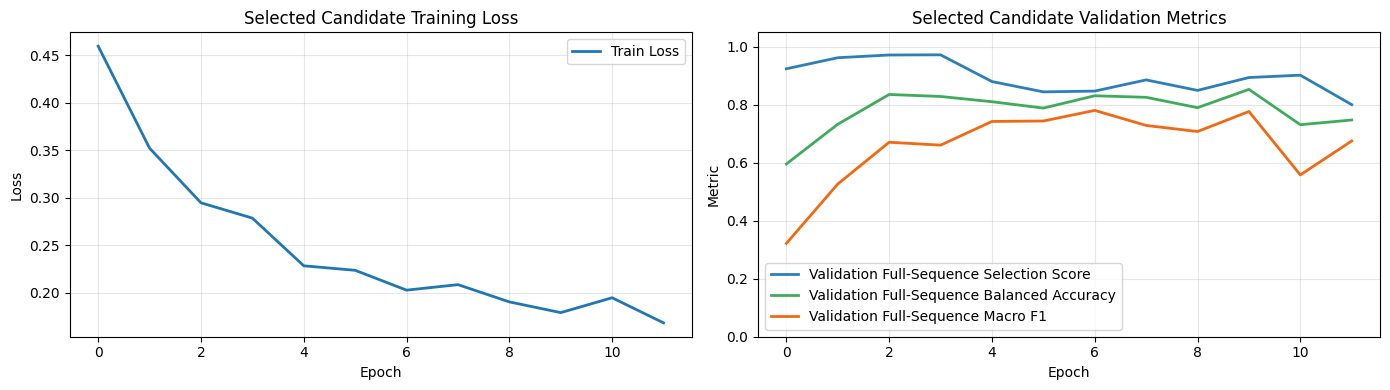

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
axes[0].set_title("Selected Candidate Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["val_full_score"], label="Validation Full-Sequence Selection Score", linewidth=2, color="#2c7fb8")
axes[1].plot(history["val_full_balanced_accuracy"], label="Validation Full-Sequence Balanced Accuracy", linewidth=2, color="#41ab5d")
axes[1].plot(history["val_full_macro_f1"], label="Validation Full-Sequence Macro F1", linewidth=2, color="#f16913")
axes[1].set_title("Selected Candidate Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Metric")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Balanced Threshold Optimization

The decision threshold is selected on validation data. The score prioritizes balanced accuracy and macro F1, rewards both classes having reasonable recall, and penalizes predicted Failure rates that drift too far above or below the actual validation Failure rate.

In [9]:
# The selected candidate has already populated failure_threshold and threshold_table.
# This table shows the best validation thresholds under the balanced objective.
threshold_table.sort_values("score", ascending=False).head(10)

,threshold,score,balanced_accuracy,macro_f1,failure_recall,success_recall,min_class_recall,actual_failure_rate,predicted_failure_rate,class_rate_gap,false_success,false_failure
0,0.05,0.972407,0.828767,0.660845,1.000000,0.657534,0.657534,0.16092,0.448276,0.287356,0,25
1,0.06,0.943836,0.834149,0.704484,0.928571,0.739726,0.739726,0.16092,0.367816,0.206897,1,19
2,0.07,0.943836,0.847847,0.726224,0.928571,0.767123,0.767123,0.16092,0.344828,0.183908,1,17
3,0.08,0.943836,0.875245,0.772761,0.928571,0.821918,0.821918,0.16092,0.298851,0.137931,1,13
4,0.09,0.943836,0.888943,0.797988,0.928571,0.849315,0.849315,0.16092,0.275862,0.114943,1,11
5,0.10,0.915264,0.853229,0.776879,0.857143,0.849315,0.849315,0.16092,0.264368,0.103448,2,11
6,0.11,0.915264,0.853229,0.776879,0.857143,0.849315,0.849315,0.16092,0.264368,0.103448,2,11
7,0.12,0.915264,0.853229,0.776879,0.857143,0.849315,0.849315,0.16092,0.264368,0.103448,2,11
8,0.13,0.915264,0.853229,0.776879,0.857143,0.849315,0.849315,0.16092,0.264368,0.103448,2,11
9,0.14,0.915264,0.866928,0.803289,0.857143,0.876712,0.857143,0.16092,0.241379,0.080460,2,9


Selected balanced threshold for P(Failure): 0.05


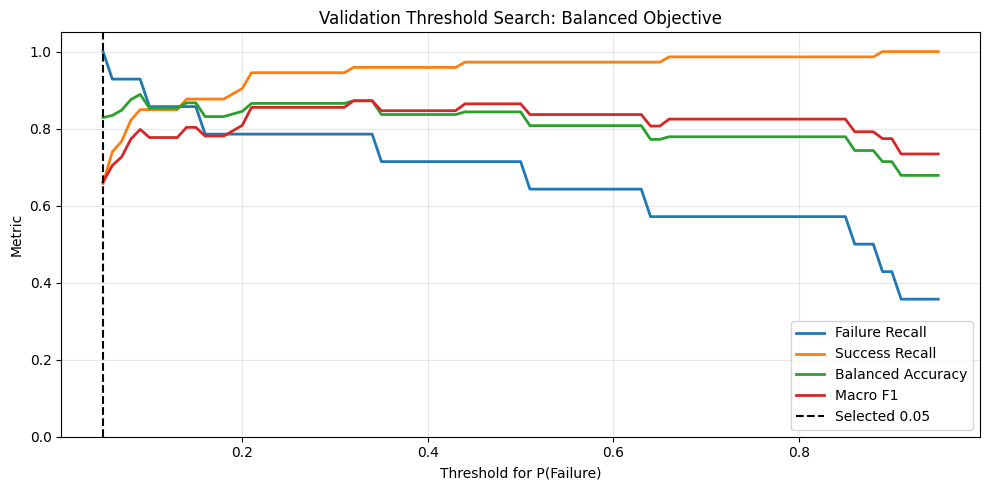

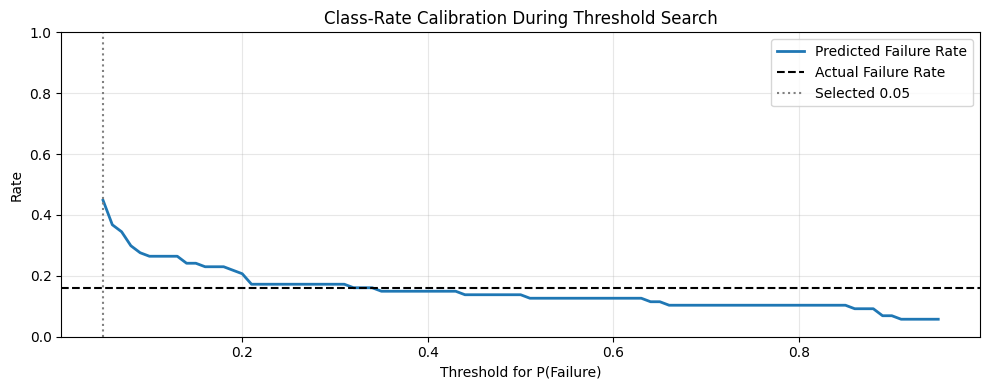

In [10]:
print(f"Selected balanced threshold for P(Failure): {failure_threshold:.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(threshold_table["threshold"], threshold_table["failure_recall"], label="Failure Recall", linewidth=2)
ax.plot(threshold_table["threshold"], threshold_table["success_recall"], label="Success Recall", linewidth=2)
ax.plot(threshold_table["threshold"], threshold_table["balanced_accuracy"], label="Balanced Accuracy", linewidth=2)
ax.plot(threshold_table["threshold"], threshold_table["macro_f1"], label="Macro F1", linewidth=2)
ax.axvline(failure_threshold, color="black", linestyle="--", label=f"Selected {failure_threshold:.2f}")
ax.set_xlabel("Threshold for P(Failure)")
ax.set_ylabel("Metric")
ax.set_ylim(0, 1.05)
ax.set_title("Validation Threshold Search: Balanced Objective")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "threshold_search.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(threshold_table["threshold"], threshold_table["predicted_failure_rate"], label="Predicted Failure Rate", linewidth=2)
ax.axhline(threshold_table["actual_failure_rate"].iloc[0], color="black", linestyle="--", label="Actual Failure Rate")
ax.axvline(failure_threshold, color="gray", linestyle=":", label=f"Selected {failure_threshold:.2f}")
ax.set_xlabel("Threshold for P(Failure)")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1.0)
ax.set_title("Class-Rate Calibration During Threshold Search")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "threshold_class_rate.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Train, Validation, and Test Evaluation

In [11]:
train_eval_pred = predict_loader(model, train_loader)
val_eval_pred = predict_loader(model, val_full_loader)
test_full_pred = predict_loader(model, test_full_loader)

train_result = evaluate_probs("train_progressive", train_eval_pred["probs"], train_eval_pred["labels"], failure_threshold)
val_result = evaluate_probs("val_m12_full_sequence", val_eval_pred["probs"], val_eval_pred["labels"], failure_threshold)
test_result = evaluate_probs("test_m12_full_sequence", test_full_pred["probs"], test_full_pred["labels"], failure_threshold)
final_deployment_status = deployment_status(train_result, val_result, test_result)

for result in [train_result, val_result, test_result]:
    print_eval(result)

print(f"\nFinal deployment status: {final_deployment_status}")


train_progressive @ threshold=0.05
accuracy             : 0.5996
balanced_accuracy    : 0.7000
macro_f1             : 0.5986
failure_precision    : 0.4500
failure_recall       : 0.9921
success_precision    : 0.9906
success_recall       : 0.4080
min_class_recall     : 0.4080
roc_auc_failure      : 0.9582867006461535
pr_auc_failure       : 0.9398922124966597
false_success_count  : 11
false_failure_count  : 1679
actual_failure_rate  : 0.3281
pred_failure_rate    : 0.7233
class_rate_gap       : 0.3952
mean P(Failure)|Failure: 0.7579
mean P(Failure)|Success: 0.0892
confusion labels [Failure, Success]: [[1374, 11], [1679, 1157]]

val_m12_full_sequence @ threshold=0.05
accuracy             : 0.7126
balanced_accuracy    : 0.8288
macro_f1             : 0.6608
failure_precision    : 0.3590
failure_recall       : 1.0000
success_precision    : 1.0000
success_recall       : 0.6575
min_class_recall     : 0.6575
roc_auc_failure      : 0.9540117416829746
pr_auc_failure       : 0.8473897134611419
fals

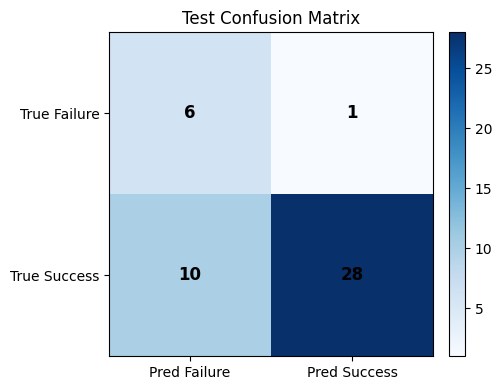

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = np.asarray(test_result.confusion_labels_failure_success)
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Pred Failure", "Pred Success"])
ax.set_yticks([0, 1], labels=["True Failure", "True Success"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black", fontsize=12, fontweight="bold")
ax.set_title("Test Confusion Matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Overfitting and Class-Bias Diagnostics

This section checks both classic overfitting and directional class bias. A balanced model should not simply predict Failure to be safe; its predicted Failure rate should be reasonably close to observed prevalence while maintaining useful recall for both classes.

In [13]:
def overfit_diagnostics(train_result, val_result, test_result):
    train_val_gap = train_result.balanced_accuracy - val_result.balanced_accuracy
    train_test_gap = train_result.balanced_accuracy - test_result.balanced_accuracy
    warnings_list = []

    if train_val_gap > 0.10:
        warnings_list.append(f"Train-validation balanced accuracy gap above target 0.10 ({train_val_gap:.4f}).")
    if train_test_gap > 0.12:
        warnings_list.append(f"Train-test balanced accuracy gap above target 0.12 ({train_test_gap:.4f}).")
    if test_result.min_class_recall < 0.50:
        warnings_list.append(f"At least one class has weak test recall ({test_result.min_class_recall:.4f}).")
    if test_result.class_rate_gap > 0.10:
        warnings_list.append(f"Predicted Failure rate is far from actual Failure rate ({test_result.class_rate_gap:.4f}).")
    if test_result.predicted_failure_rate > test_result.actual_failure_rate + 0.10:
        warnings_list.append("Failure-biased model: predicted Failure rate is higher than target tolerance.")
    if test_result.predicted_failure_rate < max(0.0, test_result.actual_failure_rate - 0.10):
        warnings_list.append("Success-biased model: predicted Failure rate is lower than target tolerance.")
    if test_result.mean_p_failure_true_failure <= test_result.mean_p_failure_true_success:
        warnings_list.append("Mean P(Failure) for true failures is not higher than for true successes.")

    print(f"Selected candidate                        : {selected_candidate['name']}")
    print(f"Selected objective                        : {selected_training_objective}")
    print(f"Selected model spec                       : {selected_model_spec}")
    print(f"Selected pos_weight                       : {selected_pos_weight}")
    print(f"Train-validation balanced accuracy gap    : {train_val_gap:.4f}")
    print(f"Train-test balanced accuracy gap          : {train_test_gap:.4f}")
    print(f"Test Failure recall                       : {test_result.failure_recall:.4f}")
    print(f"Test Success recall                       : {test_result.success_recall:.4f}")
    print(f"Test predicted Failure rate               : {test_result.predicted_failure_rate:.4f}")
    print(f"Test actual Failure rate                  : {test_result.actual_failure_rate:.4f}")
    print(f"Test class-rate gap                       : {test_result.class_rate_gap:.4f}")
    print(f"Test false-success count                  : {test_result.false_success_count}")
    print(f"Test false-failure count                  : {test_result.false_failure_count}")
    print(f"Final deployment status                   : {final_deployment_status}")

    if warnings_list:
        print("\nWarnings:")
        for warning in warnings_list:
            print(f"- {warning}")
    else:
        print("\nNo major overfitting or class-bias warning triggered by the configured thresholds.")
    return {
        "train_val_gap": train_val_gap,
        "train_test_gap": train_test_gap,
        "warnings": warnings_list,
        "deployment_status": final_deployment_status,
    }


diagnostics = overfit_diagnostics(train_result, val_result, test_result)

Selected candidate                        : h48_l1_d04_balanced_bce
Selected objective                        : balanced_bce
Selected model spec                       : {'capacity': 'h48_l1_d04', 'lstm_hidden': 48, 'lstm_layers': 1, 'dropout': 0.4, 'static_hidden': 32, 'static_out': 16, 'classifier_hidden': 32, 'loss': 'balanced_bce', 'pos_weight': None, 'name': 'h48_l1_d04_balanced_bce'}
Selected pos_weight                       : None
Train-validation balanced accuracy gap    : -0.1288
Train-test balanced accuracy gap          : -0.0970
Test Failure recall                       : 0.8571
Test Success recall                       : 0.7368
Test predicted Failure rate               : 0.3556
Test actual Failure rate                  : 0.1556
Test class-rate gap                       : 0.2000
Test false-success count                  : 1
Test false-failure count                  : 10
Final deployment status                   : ACCEPTABLE

Warnings:
- Predicted Failure rate is far from actu

## 10. Per-Month Performance M0-M12

In [14]:
def dataset_for_month(patient_idx, month):
    temporal_rows = []
    static_rows = []
    seq_lens = []
    labels = []
    patient_ids = []
    for pid in patient_idx.tolist():
        xt = np.zeros_like(X_temporal[pid], dtype=np.float32)
        xt[: month + 1] = X_temporal[pid, : month + 1]
        temporal_rows.append(xt)
        static_rows.append(X_static[pid])
        seq_lens.append(month + 1)
        labels.append(y_failure[pid])
        patient_ids.append(pid)

    class MonthDataset(Dataset):
        def __init__(self):
            self.x_temporal = torch.tensor(np.asarray(temporal_rows), dtype=torch.float32)
            self.x_static = torch.tensor(np.asarray(static_rows), dtype=torch.float32)
            self.seq_lens = torch.tensor(np.asarray(seq_lens), dtype=torch.long)
            self.labels = torch.tensor(np.asarray(labels), dtype=torch.float32)
            self.patient_ids = np.asarray(patient_ids, dtype=np.int64)
            self.months = np.full(len(patient_ids), month, dtype=np.int64)
        def __len__(self):
            return len(self.labels)
        def __getitem__(self, idx):
            return self.x_temporal[idx], self.x_static[idx], self.seq_lens[idx], self.labels[idx]
    return MonthDataset()


per_month_rows = []
per_month_predictions = []
for month in range(13):
    ds = dataset_for_month(test_idx, month)
    loader = DataLoader(ds, batch_size=256, shuffle=False)
    pred = predict_loader(model, loader)
    result = evaluate_probs(f"test_M{month}", pred["probs"], pred["labels"], failure_threshold)
    per_month_rows.append(asdict(result))
    for pid, prob, label in zip(pred["patient_ids"], pred["probs"], pred["labels"]):
        per_month_predictions.append({
            "patient_index": int(pid),
            "month": int(month),
            "true_label_failure": int(label),
            "prob_failure": float(prob),
            "pred_label_failure": int(prob >= failure_threshold),
        })

per_month_df = pd.DataFrame(per_month_rows)
per_month_df[["split", "balanced_accuracy", "failure_recall", "success_recall", "false_success_count", "mean_p_failure_true_failure", "mean_p_failure_true_success"]]

,split,balanced_accuracy,failure_recall,success_recall,false_success_count,mean_p_failure_true_failure,mean_p_failure_true_success
0,test_M0,0.618421,1.000000,0.236842,0,0.175772,0.102935
1,test_M1,0.605263,1.000000,0.210526,0,0.232192,0.096660
2,test_M2,0.546992,0.857143,0.236842,1,0.297803,0.093330
3,test_M3,0.573308,0.857143,0.289474,1,0.336240,0.079391
4,test_M4,0.607143,0.714286,0.500000,2,0.314353,0.074261
5,test_M5,0.744361,0.857143,0.631579,1,0.435471,0.070282
6,test_M6,0.796992,0.857143,0.736842,1,0.573902,0.072119
7,test_M7,0.783835,0.857143,0.710526,1,0.635032,0.070781
8,test_M8,0.783835,0.857143,0.710526,1,0.655829,0.074175
9,test_M9,0.796992,0.857143,0.736842,1,0.663106,0.077408


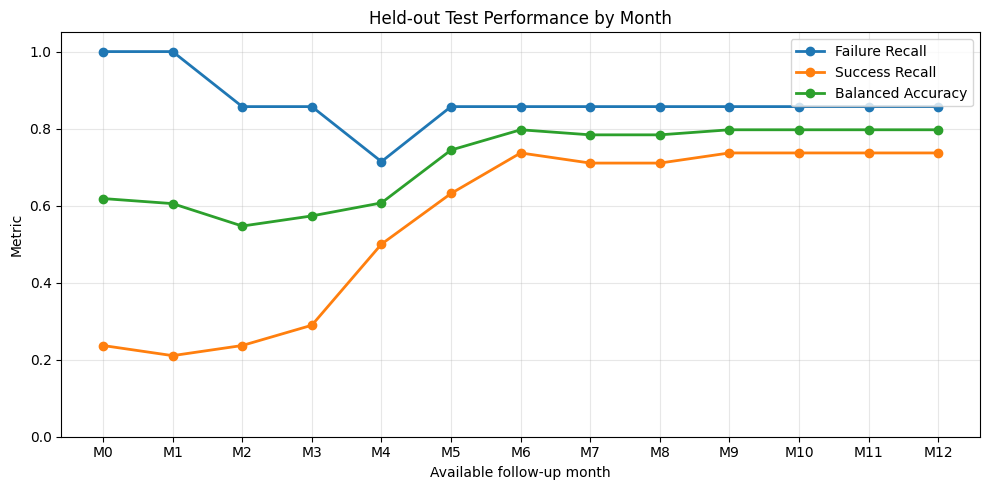

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
months = np.arange(13)
ax.plot(months, per_month_df["failure_recall"], marker="o", label="Failure Recall", linewidth=2)
ax.plot(months, per_month_df["success_recall"], marker="o", label="Success Recall", linewidth=2)
ax.plot(months, per_month_df["balanced_accuracy"], marker="o", label="Balanced Accuracy", linewidth=2)
ax.set_xticks(months, labels=[f"M{i}" for i in months])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Available follow-up month")
ax.set_ylabel("Metric")
ax.set_title("Held-out Test Performance by Month")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_month_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. False-Success Case Review

In [16]:
test_predictions_df = pd.DataFrame({
    "patient_index": test_full_pred["patient_ids"].astype(int),
    "month": test_full_pred["months"].astype(int),
    "true_label_failure": test_full_pred["labels"].astype(int),
    "prob_failure": test_full_pred["probs"].astype(float),
})
test_predictions_df["pred_label_failure"] = (test_predictions_df["prob_failure"] >= failure_threshold).astype(int)
test_predictions_df["prediction_type"] = np.select(
    [
        (test_predictions_df["true_label_failure"] == 1) & (test_predictions_df["pred_label_failure"] == 1),
        (test_predictions_df["true_label_failure"] == 0) & (test_predictions_df["pred_label_failure"] == 0),
        (test_predictions_df["true_label_failure"] == 1) & (test_predictions_df["pred_label_failure"] == 0),
        (test_predictions_df["true_label_failure"] == 0) & (test_predictions_df["pred_label_failure"] == 1),
    ],
    ["true_failure", "true_success", "false_success", "false_failure"],
    default="unknown",
)

display_cols = ["patient_index", "month", "true_label_failure", "prob_failure", "pred_label_failure", "prediction_type"]
false_success_df = test_predictions_df[test_predictions_df["prediction_type"] == "false_success"].sort_values("prob_failure")
print(f"False-success cases: {len(false_success_df)}")
false_success_df[display_cols]

False-success cases: 1


,patient_index,month,true_label_failure,prob_failure,pred_label_failure,prediction_type
17,185,12,1,0.026162,0,false_success


## 12. Clinical Sanity Checks

In [17]:
def predict_single(patient_idx, month, temporal_override=None):
    xt = np.zeros_like(X_temporal[patient_idx], dtype=np.float32)
    xt[: month + 1] = X_temporal[patient_idx, : month + 1]
    if temporal_override is not None:
        xt[: month + 1] = temporal_override(xt[: month + 1].copy())
    xs = X_static[patient_idx]
    model.eval()
    with torch.no_grad():
        logit, _ = model(
            torch.tensor(xt[None, :, :], dtype=torch.float32, device=DEVICE),
            torch.tensor(xs[None, :], dtype=torch.float32, device=DEVICE),
            seq_lens=torch.tensor([month + 1], dtype=torch.long, device=DEVICE),
        )
    return float(torch.sigmoid(logit).cpu().item())


feature_to_idx = {name: i for i, name in enumerate(temporal_feature_names)}
adherence_idx = feature_to_idx.get("pct_adherence")
missed_idx = feature_to_idx.get("monthly_missed_doses")
smear_idx = feature_to_idx.get("smear_tb_lamp")
xpert_idx = feature_to_idx.get("xpert_mtb_rif")

def high_risk_override(seq):
    if adherence_idx is not None:
        seq[:, adherence_idx] = np.nanmin(X_temporal[:, :, adherence_idx])
    if missed_idx is not None:
        seq[:, missed_idx] = np.nanmax(X_temporal[:, :, missed_idx])
    if smear_idx is not None:
        seq[:, smear_idx] = np.nanmax(X_temporal[:, :, smear_idx])
    if xpert_idx is not None:
        seq[:, xpert_idx] = np.nanmax(X_temporal[:, :, xpert_idx])
    return seq

def low_risk_override(seq):
    if adherence_idx is not None:
        seq[:, adherence_idx] = np.nanmax(X_temporal[:, :, adherence_idx])
    if missed_idx is not None:
        seq[:, missed_idx] = np.nanmin(X_temporal[:, :, missed_idx])
    if smear_idx is not None:
        seq[:, smear_idx] = np.nanmin(X_temporal[:, :, smear_idx])
    if xpert_idx is not None:
        seq[:, xpert_idx] = np.nanmin(X_temporal[:, :, xpert_idx])
    return seq

example_pid = int(test_idx[0])
sanity_rows = []
for month in [0, 1, 3, 6, 12]:
    base = predict_single(example_pid, month)
    low = predict_single(example_pid, month, low_risk_override)
    high = predict_single(example_pid, month, high_risk_override)
    sanity_rows.append({"month": f"M{month}", "baseline_p_failure": base, "low_risk_p_failure": low, "high_risk_p_failure": high})

sanity_df = pd.DataFrame(sanity_rows)
print("Sanity expectation: high-risk override should generally be higher than low-risk override.")
sanity_df

Sanity expectation: high-risk override should generally be higher than low-risk override.


,month,baseline_p_failure,low_risk_p_failure,high_risk_p_failure
0,M0,0.267765,0.267765,0.960534
1,M1,0.211666,0.211666,0.964025
2,M3,0.093225,0.093225,0.964993
3,M6,0.045386,0.045386,0.973154
4,M12,0.037893,0.037893,0.981721


## 13. Save Model Artifacts

In [18]:
checkpoint = {
    "model_state_dict": best_state,
    "threshold": failure_threshold,
    "label_convention": "1=Failure, 0=Success",
    "output_probability": "P(Failure)",
    "training_objective": selected_training_objective,
    "selection_objective": selected_selection_objective,
    "model_spec": selected_model_spec,
    "pos_weight": selected_pos_weight,
    "deployment_status": final_deployment_status,
    "created_at": datetime.now().isoformat(timespec="seconds"),
}
torch.save(checkpoint, OUTPUT_DIR / "best_model.pt")

config = {
    "model_type": "Hybrid Bi-LSTM temporal CDSS",
    "label_convention": "1=Failure, 0=Success",
    "output_probability": "P(Failure)",
    "threshold": failure_threshold,
    "training_objective": selected_training_objective,
    "selection_objective": selected_selection_objective,
    "model_spec": selected_model_spec,
    "pos_weight": selected_pos_weight,
    "selection_score": selected_candidate["selection_score"],
    "selection_reason": selection_reason,
    "deployment_status": final_deployment_status,
    "candidate_validation_results": {
        row["name"]: {
            "spec": row["spec"],
            "pos_weight": row["pos_weight"],
            "selection_score": row["selection_score"],
            "threshold": row["threshold"],
            "train_metrics": asdict(row["train_result"]),
            "validation_metrics": asdict(row["val_result"]),
        }
        for row in candidate_results
    },
    "seed": SEED,
    "temporal_features": int(X_temporal.shape[2]),
    "static_features": int(X_static.shape[1]),
    "feature_policy_version": feature_policy_version,
    "dropped_feature_cols": dropped_feature_cols,
    "static_feature_names": static_feature_names,
    "temporal_feature_names": temporal_feature_names,
    "static_missing_indicator_names": static_mnar_indicators,
    "temporal_missing_indicator_names": temporal_mnar_indicators,
    "split_counts": {
        "train": split_counts(train_idx),
        "val": split_counts(val_idx),
        "test": split_counts(test_idx),
    },
    "metrics": {
        "train_progressive": asdict(train_result),
        "val_m12_full_sequence": asdict(val_result),
        "test_m12_full_sequence": asdict(test_result),
    },
    "overfit_diagnostics": diagnostics,
}
(OUTPUT_DIR / "model_config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")

test_predictions_df.to_csv(OUTPUT_DIR / "predictions.csv", index=False)
pd.DataFrame(per_month_predictions).to_csv(OUTPUT_DIR / "per_month_predictions.csv", index=False)
per_month_df.to_csv(OUTPUT_DIR / "per_month_metrics.csv", index=False)
threshold_table.to_csv(OUTPUT_DIR / "threshold_search.csv", index=False)

report_lines = [
    "Overfit-Reduced Balanced Hybrid Bi-LSTM Failure-Risk Evaluation",
    "===============================================================",
    f"Created at: {checkpoint['created_at']}",
    f"Label convention: {config['label_convention']}",
    f"Output probability: {config['output_probability']}",
    f"Selected candidate: {selected_candidate['name']}",
    f"Training objective: {selected_training_objective}",
    f"Selection objective: {selected_selection_objective}",
    f"Model spec: {selected_model_spec}",
    f"Pos weight: {selected_pos_weight}",
    f"Threshold: {failure_threshold:.4f}",
    f"Deployment status: {final_deployment_status}",
    "",
]
for result in [train_result, val_result, test_result]:
    report_lines.extend([
        result.split,
        "-" * len(result.split),
        json.dumps(asdict(result), indent=2),
        "",
    ])
report_lines.extend(["Overfit and class-bias diagnostics", "-----------------------------------", json.dumps(diagnostics, indent=2)])
(OUTPUT_DIR / "evaluation_report.txt").write_text("\n".join(report_lines), encoding="utf-8")

print(f"Saved artifacts to: {OUTPUT_DIR}")
print("- best_model.pt")
print("- model_config.json")
print("- evaluation_report.txt")
print("- predictions.csv")
print("- per_month_metrics.csv")
print("- per_month_predictions.csv")
print("- threshold_search.csv")

Saved artifacts to: C:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\hybrid_lstm_failure_positive
- best_model.pt
- model_config.json
- evaluation_report.txt
- predictions.csv
- per_month_metrics.csv
- per_month_predictions.csv
- threshold_search.csv


## 14. Export PT to ONNX and Optional ORT Format

This cell exports the selected `best_model.pt` checkpoint to ONNX for browser inference and writes metadata needed by the frontend scaler/feature builder. The ONNX output is still a raw logit; the web app should compute `failureProbability = sigmoid(logit)`.

If `onnxruntime` provides the ORT conversion tool in the environment, the cell also attempts to create an optimized `.ort` model. ONNX remains the portable default used by `onnxruntime-web`.

In [19]:
# Temperature scaling (calibrate probabilities on validation logits)

with torch.no_grad():
    model.eval()
    logits_list = []
    labels_list = []
    for x_t, x_s, seq_lens, labels in val_full_loader:
        x_t = x_t.to(DEVICE)
        x_s = x_s.to(DEVICE)
        seq_lens = seq_lens.to(DEVICE)
        labels = labels.to(DEVICE)
        logits, _ = model(x_t, x_s, seq_lens=seq_lens)
        logits_list.append(logits.detach())
        labels_list.append(labels.detach())

val_logits = torch.cat(logits_list).float()
val_labels = torch.cat(labels_list).float()

# Optimize a single temperature scalar (T>0) to minimize NLL.
log_T = torch.zeros((), device=DEVICE, requires_grad=True)
opt = torch.optim.LBFGS([log_T], lr=0.5, max_iter=200, line_search_fn='strong_wolfe')

bce = torch.nn.BCEWithLogitsLoss()

def closure():
    opt.zero_grad(set_to_none=True)
    T = torch.exp(log_T).clamp(min=1e-3, max=100.0)
    loss = bce(val_logits / T, val_labels)
    loss.backward()
    return loss

opt.step(closure)
T = float(torch.exp(log_T).detach().cpu().item())

# Fallback safety.
if not (T > 1e-6 and T < 1e6):
    T = 1.0

temperature = float(T)
print(f'Temperature scaling fitted: T={temperature:.4f}')

# Platt scaling (logistic regression over raw logit on val set).
from sklearn.linear_model import LogisticRegression as _LR
_val_logits_np = val_logits.cpu().numpy().reshape(-1, 1)
_val_labels_np = val_labels.cpu().numpy().astype(int)
_platt = _LR(C=1.0, solver="lbfgs").fit(_val_logits_np, _val_labels_np)
platt_a = float(_platt.coef_[0, 0])
platt_b = float(_platt.intercept_[0])
print(f'Platt scaling fitted: a={platt_a:.4f}, b={platt_b:.4f}')


Temperature scaling fitted: T=0.9468
Platt scaling fitted: a=0.9548, b=-0.2541


In [20]:
# Clinical counterfactual sanity gate (pre-export)
# Reject models that reduce risk when adherence becomes very poor.

feat_to_i = {n: i for i, n in enumerate(temporal_feature_names)}

mean_t = np.asarray(scaled["temporal_full_mean"], dtype=np.float32)
scale_t = np.asarray(scaled["temporal_full_scale"], dtype=np.float32)

static_scaled = np.zeros((len(static_feature_names),), dtype=np.float32)

raw = np.full((13, len(temporal_feature_names)), np.nan, dtype=np.float32)
for n in temporal_feature_names:
    if n.startswith("is_missing_"):
        raw[:, feat_to_i[n]] = 1.0

if "smear_tb_lamp" in feat_to_i:
    raw[0, feat_to_i["smear_tb_lamp"]] = 1.0
if "is_missing_smear_tb_lamp" in feat_to_i:
    raw[0, feat_to_i["is_missing_smear_tb_lamp"]] = 0.0
if "is_missing_xpert_mtb_rif" in feat_to_i:
    raw[0, feat_to_i["is_missing_xpert_mtb_rif"]] = 1.0

raw_A = raw.copy()

raw_low = raw.copy()
for k, v in [
    ("weight", 55.0), ("height", 155.0), ("monthly_doses_taken", 19.0),
    ("monthly_missed_doses", 0.0), ("cumulative_doses_taken", 19.0),
    ("pct_adherence", 1.0), ("smear_tb_lamp", 0.0), ("xpert_mtb_rif", 0.0),
]:
    if k in feat_to_i:
        raw_low[1, feat_to_i[k]] = float(v)
for k in [
    "is_missing_weight", "is_missing_height", "is_missing_monthly_doses_taken",
    "is_missing_monthly_missed_doses", "is_missing_cumulative_doses_taken",
    "is_missing_pct_adherence", "is_missing_smear_tb_lamp", "is_missing_xpert_mtb_rif",
]:
    if k in feat_to_i:
        raw_low[1, feat_to_i[k]] = 0.0

raw_B = raw.copy()
for k, v in [
    ("weight", 55.0), ("height", 155.0), ("monthly_doses_taken", 2.0),
    ("monthly_missed_doses", 17.0), ("cumulative_doses_taken", 2.0),
    ("pct_adherence", 2.0 / 19.0), ("smear_tb_lamp", 1.0), ("xpert_mtb_rif", 1.0),
]:
    if k in feat_to_i:
        raw_B[1, feat_to_i[k]] = float(v)
for k in [
    "is_missing_weight", "is_missing_height", "is_missing_monthly_doses_taken",
    "is_missing_monthly_missed_doses", "is_missing_cumulative_doses_taken",
    "is_missing_pct_adherence", "is_missing_smear_tb_lamp", "is_missing_xpert_mtb_rif",
]:
    if k in feat_to_i:
        raw_B[1, feat_to_i[k]] = 0.0

X_A = np.nan_to_num((raw_A - mean_t) / scale_t, nan=0.0).astype(np.float32)
X_low = np.nan_to_num((raw_low - mean_t) / scale_t, nan=0.0).astype(np.float32)
X_B = np.nan_to_num((raw_B - mean_t) / scale_t, nan=0.0).astype(np.float32)

with torch.no_grad():
    model.eval()
    xtA   = torch.tensor(X_A.reshape(1, 13, -1),   dtype=torch.float32, device=DEVICE)
    xtB   = torch.tensor(X_B.reshape(1, 13, -1),   dtype=torch.float32, device=DEVICE)
    xtLow = torch.tensor(X_low.reshape(1, 13, -1), dtype=torch.float32, device=DEVICE)
    xs    = torch.tensor(static_scaled.reshape(1, -1), dtype=torch.float32, device=DEVICE)
    logit_A, _ = model(xtA,   xs, seq_lens=torch.tensor([1], dtype=torch.long, device=DEVICE))
    logit_L, _ = model(xtLow, xs, seq_lens=torch.tensor([2], dtype=torch.long, device=DEVICE))
    logit_B, _ = model(xtB,   xs, seq_lens=torch.tensor([2], dtype=torch.long, device=DEVICE))
    pA   = float(torch.sigmoid(logit_A / temperature).detach().cpu().numpy().reshape(-1)[0])
    pLow = float(torch.sigmoid(logit_L / temperature).detach().cpu().numpy().reshape(-1)[0])
    pB   = float(torch.sigmoid(logit_B / temperature).detach().cpu().numpy().reshape(-1)[0])

print(f"Clinical gate: baseline M0     P(failure)={pA:.4f}")
print(f"Clinical gate: low-risk  M1    P(failure)={pLow:.4f}")
print(f"Clinical gate: high-risk M1    P(failure)={pB:.4f}")
print(f"Clinical gate: delta (high-base)={pB - pA:.4f}  sep (high-low)={pB - pLow:.4f}")

# Gate enforces discrimination capability, not absolute calibration.
# Platt scaling (fitted above) handles calibration at inference time.
NONDEGEN_MIN  = 0.001   # prevent all-success collapse
NONDEGEN_MAX  = 0.999   # prevent all-failure collapse
HIGHRISK_MIN  = 0.20    # high-risk M1 must predict non-trivial failure risk
DELTA_MIN     = 0.05    # baseline vs high-risk must differ by >= 5 pp
SEP_MIN       = 0.15    # low-risk M1 vs high-risk M1 must differ by >= 15 pp

if not (NONDEGEN_MIN <= pA <= NONDEGEN_MAX):
    raise RuntimeError(f"Clinical gate FAILED: baseline M0 risk {pA:.4f} is degenerate.")
if not (pB >= HIGHRISK_MIN):
    raise RuntimeError(f"Clinical gate FAILED: high-risk M1 risk {pB:.4f} < {HIGHRISK_MIN:.2f}.")
if not ((pB - pA) >= DELTA_MIN):
    raise RuntimeError(f"Clinical gate FAILED: delta {pB - pA:.4f} below {DELTA_MIN:.2f}.")
if not ((pB - pLow) >= SEP_MIN):
    raise RuntimeError(f"Clinical gate FAILED: separation (high-low) {pB - pLow:.4f} below {SEP_MIN:.2f}.")

print("Clinical gate: PASSED")


Clinical gate: baseline M0     P(failure)=0.8610
Clinical gate: low-risk  M1    P(failure)=0.0177
Clinical gate: high-risk M1    P(failure)=0.9955
Clinical gate: delta (high-base)=0.1345  sep (high-low)=0.9778
Clinical gate: PASSED


In [21]:
class OnnxFailureRiskWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x_temporal, x_static, seq_lens):
        logit, _ = self.model(x_temporal, x_static, seq_lens=seq_lens)
        return logit


onnx_dir = REPO_ROOT / "web-app" / "public" / "model"
onnx_dir.mkdir(parents=True, exist_ok=True)
onnx_path = onnx_dir / "hybrid_lstm_temporal.onnx"
metadata_path = onnx_dir / "hybrid_lstm_temporal_metadata.json"

model.eval()
onnx_model = OnnxFailureRiskWrapper(model).to(DEVICE).eval()
dummy_temporal = torch.zeros(1, X_temporal.shape[1], X_temporal.shape[2], dtype=torch.float32, device=DEVICE)
dummy_static = torch.zeros(1, X_static.shape[1], dtype=torch.float32, device=DEVICE)
dummy_seq_lens = torch.tensor([min(13, max(1, int(X_temporal.shape[1])))], dtype=torch.long, device=DEVICE)

torch.onnx.export(
    onnx_model,
    (dummy_temporal, dummy_static, dummy_seq_lens),
    str(onnx_path),
    input_names=["x_temporal", "x_static", "seq_lens"],
    output_names=["logit"],
    dynamic_axes={
        "x_temporal": {0: "batch", 1: "months"},
        "x_static": {0: "batch"},
        "seq_lens": {0: "batch"},
        "logit": {0: "batch"},
    },
    opset_version=17,
    do_constant_folding=True,
    dynamo=False,
)

metadata = {
    "modelType": "hybrid_lstm_temporal_balanced_failure_risk_composite_auc_recallF",
    "labelConvention": "1=Failure, 0=Success",
    "outputProbability": "P(Failure)",
    "logitMeaning": "sigmoid(logit) = failureProbability",
    "threshold": failure_threshold,
    "trainingObjective": selected_training_objective,
    "selectionObjective": selected_selection_objective,
    "modelSpec": selected_model_spec,
    "posWeight": selected_pos_weight,
    "deploymentStatus": final_deployment_status,
    "temperature": float(temperature),
    "platt": {"a": platt_a, "b": platt_b},
    "temporalFeatureNames": temporal_feature_names,
    "staticFeatureNames": static_feature_names,
    "temporalScaler": {
        "mean": np.asarray(scaled["temporal_full_mean"], dtype=float).tolist(),
        "scale": np.asarray(scaled["temporal_full_scale"], dtype=float).tolist(),
    },
    "staticScaler": {
        "mean": np.asarray(scaled["static_full_mean"], dtype=float).tolist(),
        "scale": np.asarray(scaled["static_full_scale"], dtype=float).tolist(),
    },
    "featurePolicyVersion": feature_policy_version,
    "createdAt": datetime.now().isoformat(timespec="seconds"),
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Exported ONNX model: {onnx_path}")
print(f"Exported metadata  : {metadata_path}")

try:
    import onnxruntime as ort

    session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
    ort_logit = session.run(None, {
        "x_temporal": dummy_temporal.cpu().numpy(),
        "x_static": dummy_static.cpu().numpy(),
        "seq_lens": dummy_seq_lens.cpu().numpy(),
    })[0]
    print(f"ONNX Runtime validation logit shape: {ort_logit.shape}")
except Exception as exc:
    print(f"ONNX Runtime validation skipped: {exc}")

try:
    import subprocess

    result = subprocess.run(
        [
            sys.executable,
            "-m",
            "onnxruntime.tools.convert_onnx_models_to_ort",
            str(onnx_dir),
        ],
        capture_output=True,
        text=True,
        check=False,
    )
    if result.returncode == 0:
        print("ORT conversion completed. Check web-app/public/model for generated .ort files.")
    else:
        print("ORT conversion was not completed by this environment.")
        print(result.stderr.strip() or result.stdout.strip())
except Exception as exc:
    print(f"ORT conversion skipped: {exc}")


Exported ONNX model: C:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\web-app\public\model\hybrid_lstm_temporal.onnx
Exported metadata  : C:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\web-app\public\model\hybrid_lstm_temporal_metadata.json


ONNX Runtime validation logit shape: (1,)


ORT conversion completed. Check web-app/public/model for generated .ort files.
